# Simulación de Inferencia en Tiempo Real — Detección de Vishing

Corre el simulador de inferencia sobre las 100K sesiones sintéticas enviando cada observación
**una a una** al `VishingModelWrapper`, mide la latencia en ms y genera el dashboard de resultados.

**Prerequisitos:**
- `10_Inference_Data_Generation.ipynb` ejecutado → parquet en S3
- Al menos un modelo entrenado (Notebook 7 o Notebook 9) disponible en S3
- `realtime_simulator.py` en el mismo directorio de trabajo

## Configuración (única celda a editar)

In [26]:
# ── CONFIGURA AQUÍ ────────────────────────────────────────────────────────────

# Ruta S3 del VishingModelWrapper a evaluar
WRAPPER_S3_PATH = 's3://poc-fraude-vishing/proyecto/modelos_xgb/augmented/xgb_deep/random_oversampling/25.pkl'

# Ruta S3 del dataset de inferencia generado en el Notebook 10
DATA_S3_PATH = 's3://poc-fraude-vishing/proyecto/data/inference_simulation/inference_100k.parquet'

BUCKET         = 'poc-fraude-vishing'
RESULTS_PREFIX = 'proyecto/data/inference_simulation/results'

# ─────────────────────────────────────────────────────────────────────────────
print(f'Modelo : {WRAPPER_S3_PATH}')
print(f'Data   : {DATA_S3_PATH}')

Modelo : s3://poc-fraude-vishing/proyecto/modelos_xgb/augmented/xgb_deep/random_oversampling/25.pkl
Data   : s3://poc-fraude-vishing/proyecto/data/inference_simulation/inference_100k.parquet


In [6]:
%pip install --quiet "sagemaker<3" tqdm


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
import pandas as pd
import numpy as np
import boto3
import sagemaker
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from realtime_simulator import RealtimeInferenceSimulator

sagemaker_session = sagemaker.Session()
print('Librerías cargadas.')

Librerías cargadas.


In [28]:
import realtime_simulator

print(dir(realtime_simulator))

['BytesIO', 'RealtimeInferenceSimulator', '_TQDM_AVAILABLE', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'boto3', 'joblib', 'np', 'pd', 'time', 'tqdm', 'urlparse']


In [29]:
class VishingModelWrapper:
    """
    Bundles a trained XGBoost model with its feature list and optimal
    decision threshold. Accepts dict, JSON string, or list[dict] as input.
    """

    def __init__(self, model, feature_names, threshold=0.5,
                 model_name='', technique='', ratio='', data_type=''):
        self.model         = model
        self.feature_names = list(feature_names)
        self.threshold     = threshold
        self.model_name    = model_name
        self.technique     = technique
        self.ratio         = ratio
        self.data_type     = data_type  # 'augmented' | 'original'

    def _to_array(self, json_input):
        if isinstance(json_input, str):
            data = _json.loads(json_input)
        elif isinstance(json_input, dict):
            data = json_input
        elif isinstance(json_input, list):
            return np.vstack([self._to_array(item) for item in json_input])
        else:
            raise TypeError(f'Expected dict, JSON string, or list. Got {type(json_input)}')
        missing = set(self.feature_names) - set(data.keys())
        if missing:
            raise ValueError(f'Missing features: {sorted(missing)}')
        return np.array([[data[f] for f in self.feature_names]], dtype=np.float64)

    def predict(self, json_input):
        proba  = self.model.predict_proba(self._to_array(json_input))[:, 1]
        labels = (proba >= self.threshold).astype(int).tolist()
        return labels[0] if len(labels) == 1 else labels

    def predict_proba_raw(self, json_input):
        proba = self.model.predict_proba(self._to_array(json_input))
        rows  = [{'legitimate': round(float(p[0]), 6), 'vishing': round(float(p[1]), 6)}
                 for p in proba]
        return rows[0] if len(rows) == 1 else rows

    def predict_full(self, json_input):
        proba   = self.model.predict_proba(self._to_array(json_input))
        results = []
        for p in proba:
            label = int(p[1] >= self.threshold)
            results.append({
                'prediction':             label,
                'label':                  'vishing' if label == 1 else 'legitimate',
                'probability_vishing':    round(float(p[1]), 6),
                'probability_legitimate': round(float(p[0]), 6),
                'threshold_used':         round(self.threshold, 6),
            })
        return results[0] if len(results) == 1 else results

    def __repr__(self):
        return (f'VishingModelWrapper(variant={self.model_name!r}, '
                f'data={self.data_type!r}, technique={self.technique!r}, '
                f'ratio={self.ratio!r}, n_features={len(self.feature_names)}, '
                f'threshold={self.threshold:.4f})')

## 1. Creación del simulador

In [30]:
simulator = RealtimeInferenceSimulator(
    wrapper_s3_path   = WRAPPER_S3_PATH,
    data_s3_path      = DATA_S3_PATH,
    bucket            = BUCKET,
    results_s3_prefix = RESULTS_PREFIX,
)

# Carga explícita para inspeccionar antes de correr
simulator.load_model()
simulator.load_data()

[Simulador] Modelo cargado  : VishingModelWrapper(variant='xgb_deep', data='augmented', technique='random_oversampling', ratio='25', n_features=44, threshold=0.9365)
[Simulador] Data cargada    : 100,000 observaciones — vishing 1.50%


## 2. Ejecución del flujo en tiempo real
Cada observación se envía individualmente como `dict` al wrapper y se mide la latencia con `time.perf_counter()`.

In [31]:
df_results = simulator.run(show_progress=True)

Inferencia en tiempo real:   0%|          | 101/100000 [00:00<03:14, 513.36it/s]

[Simulador] Iniciando simulación — 100,000 observaciones individuales...


Inferencia en tiempo real: 100%|██████████| 100000/100000 [03:05<00:00, 538.61it/s]


[Simulador] Simulación completada en 185.7s  (539 obs/s)


## 3. Guardar resultados en S3 y calcular métricas

In [32]:
results_path = simulator.save_results('simulation_results.csv')

metrics = simulator.compute_metrics()

print('\n' + '='*65)
print('  RESUMEN DE LA SIMULACIÓN')
print('='*65)
print(f'  Observaciones procesadas : {metrics["total_obs"]:>10,}')

if 'total_vishing' in metrics:
    print(f'  Sesiones vishing reales  : {metrics["total_vishing"]:>10,}  '
          f'({metrics["total_vishing"]/metrics["total_obs"]*100:.2f}%)')
    print(f'  Sesiones legítimas reales: {metrics["total_legitimate"]:>10,}')

print(f'\n  ALERTAS GENERADAS')
print(f'  Total alertas            : {metrics["total_alerts"]:>10,}')
print(f'  Tasa de alerta           : {metrics["alert_rate_pct"]:>10.4f}%')

if 'recall' in metrics:
    print(f'\n  MÉTRICAS DE DETECCIÓN')
    print(f'  Vishing detectados (TP)  : {metrics["vishing_detected"]:>10,}')
    print(f'  Vishing perdidos (FN)    : {metrics["vishing_missed"]:>10,}')
    print(f'  Falsas alertas (FP)      : {metrics["false_alerts"]:>10,}')
    print(f'  Recall                   : {metrics["recall"]:>10.4f}')
    print(f'  Precision                : {metrics["precision"]:>10.4f}')
    print(f'  F1                       : {metrics["f1"]:>10.4f}')

print(f'\n  LATENCIA DE INFERENCIA (ms)')
print(f'  Media                    : {metrics["lat_mean_ms"]:>10.4f} ms')
print(f'  Mediana (p50)            : {metrics["lat_median_ms"]:>10.4f} ms')
print(f'  p95                      : {metrics["lat_p95_ms"]:>10.4f} ms')
print(f'  p99                      : {metrics["lat_p99_ms"]:>10.4f} ms')
print(f'  Máximo                   : {metrics["lat_max_ms"]:>10.4f} ms')
print('='*65)

[Simulador] Resultados guardados en: s3://poc-fraude-vishing/proyecto/data/inference_simulation/results/simulation_results.csv

  RESUMEN DE LA SIMULACIÓN
  Observaciones procesadas :    100,000
  Sesiones vishing reales  :      1,500  (1.50%)
  Sesiones legítimas reales:     98,500

  ALERTAS GENERADAS
  Total alertas            :      1,470
  Tasa de alerta           :     1.4700%

  MÉTRICAS DE DETECCIÓN
  Vishing detectados (TP)  :      1,133
  Vishing perdidos (FN)    :        367
  Falsas alertas (FP)      :        337
  Recall                   :     0.7553
  Precision                :     0.7707
  F1                       :     0.7630

  LATENCIA DE INFERENCIA (ms)
  Media                    :     1.5978 ms
  Mediana (p50)            :     1.5273 ms
  p95                      :     1.7939 ms
  p99                      :     2.2447 ms
  Máximo                   :    49.4515 ms


## 4. Dashboard de resultados
### 4.1 Distribución de latencias

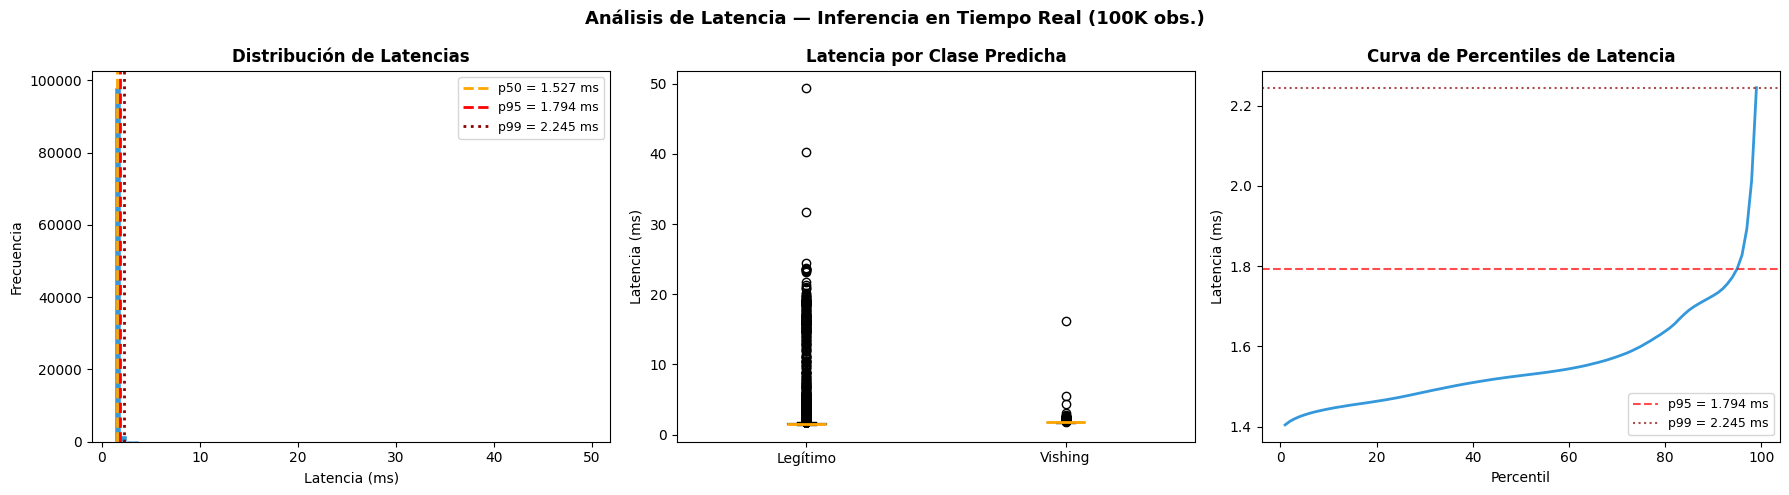

In [33]:
lat = df_results['latency_ms']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
axes[0].hist(lat, bins=80, color='#3498db', edgecolor='white', linewidth=0.3)
axes[0].axvline(metrics['lat_median_ms'], color='orange', linestyle='--',
                linewidth=2, label=f'p50 = {metrics["lat_median_ms"]:.3f} ms')
axes[0].axvline(metrics['lat_p95_ms'],    color='red',    linestyle='--',
                linewidth=2, label=f'p95 = {metrics["lat_p95_ms"]:.3f} ms')
axes[0].axvline(metrics['lat_p99_ms'],    color='darkred', linestyle=':',
                linewidth=2, label=f'p99 = {metrics["lat_p99_ms"]:.3f} ms')
axes[0].set_xlabel('Latencia (ms)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Latencias', fontweight='bold')
axes[0].legend(fontsize=9)

# Boxplot por clase predicha
df_results['Predicción'] = df_results['label_pred'].map(
    {'legitimate': 'Legítimo', 'vishing': 'Vishing'})
bp_data = [df_results[df_results['label_pred'] == c]['latency_ms'].values
           for c in ['legitimate', 'vishing']]
axes[1].boxplot(bp_data, labels=['Legítimo', 'Vishing'],
                patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.6),
                medianprops=dict(color='orange', linewidth=2))
axes[1].set_ylabel('Latencia (ms)')
axes[1].set_title('Latencia por Clase Predicha', fontweight='bold')

# Percentiles acumulados
pcts  = np.arange(1, 100)
vals  = np.percentile(lat, pcts)
axes[2].plot(pcts, vals, color='#3498db', linewidth=2)
axes[2].axhline(metrics['lat_p95_ms'], color='red',    linestyle='--',
                alpha=0.7, label=f'p95 = {metrics["lat_p95_ms"]:.3f} ms')
axes[2].axhline(metrics['lat_p99_ms'], color='darkred', linestyle=':',
                alpha=0.7, label=f'p99 = {metrics["lat_p99_ms"]:.3f} ms')
axes[2].set_xlabel('Percentil')
axes[2].set_ylabel('Latencia (ms)')
axes[2].set_title('Curva de Percentiles de Latencia', fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Análisis de Latencia — Inferencia en Tiempo Real (100K obs.)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Distribución de scores y detección

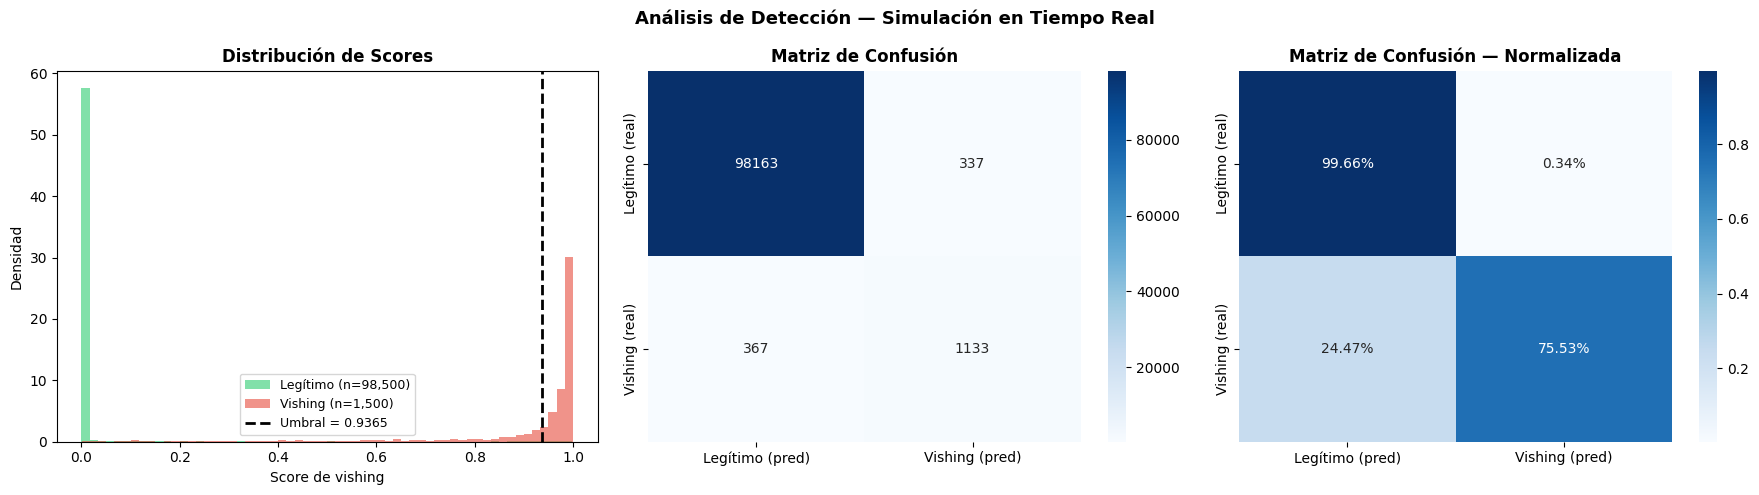

In [34]:
has_gt = 'is_vishing_real' in df_results.columns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribución de score_vishing
if has_gt:
    for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
        subset = df_results[df_results['is_vishing_real'] == label]['score_vishing']
        axes[0].hist(subset, bins=60, alpha=0.6, color=color,
                     label=f'{"Legítimo" if label==0 else "Vishing"} (n={len(subset):,})',
                     density=True)
else:
    axes[0].hist(df_results['score_vishing'], bins=60, color='#3498db', alpha=0.7, density=True)

thr = df_results['threshold_used'].iloc[0]
axes[0].axvline(thr, color='black', linestyle='--', linewidth=2, label=f'Umbral = {thr:.4f}')
axes[0].set_xlabel('Score de vishing')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de Scores', fontweight='bold')
axes[0].legend(fontsize=9)

# Matriz de confusión (si hay ground truth)
if has_gt:
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(df_results['is_vishing_real'], df_results['prediction'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
                xticklabels=['Legítimo (pred)', 'Vishing (pred)'],
                yticklabels=['Legítimo (real)', 'Vishing (real)'])
    axes[1].set_title('Matriz de Confusión', fontweight='bold')

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[2],
                xticklabels=['Legítimo (pred)', 'Vishing (pred)'],
                yticklabels=['Legítimo (real)', 'Vishing (real)'])
    axes[2].set_title('Matriz de Confusión — Normalizada', fontweight='bold')
else:
    counts = df_results['label_pred'].value_counts()
    axes[1].bar(counts.index, counts.values,
                color=['#2ecc71', '#e74c3c'])
    axes[1].set_title('Distribución de Predicciones', fontweight='bold')
    axes[2].axis('off')

plt.suptitle('Análisis de Detección — Simulación en Tiempo Real',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Latencia en el tiempo (primeras 5,000 observaciones)

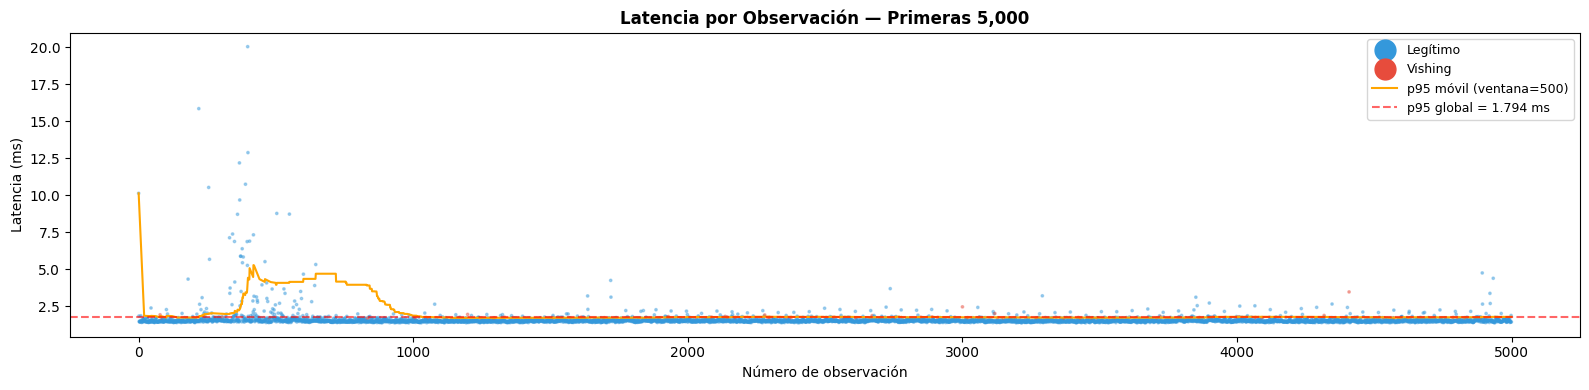

In [35]:
sample = df_results.head(5_000).copy()
sample['rolling_p95'] = sample['latency_ms'].rolling(500, min_periods=1).quantile(0.95)

fig, ax = plt.subplots(figsize=(16, 4))

if has_gt:
    colors = sample['is_vishing_real'].map({0: '#3498db', 1: '#e74c3c'})
    ax.scatter(sample.index, sample['latency_ms'], c=colors, s=3, alpha=0.4)
    ax.plot([], [], 'o', color='#3498db', markersize=5, label='Legítimo')
    ax.plot([], [], 'o', color='#e74c3c', markersize=5, label='Vishing')
else:
    ax.scatter(sample.index, sample['latency_ms'], s=3, alpha=0.3, color='#3498db')

ax.plot(sample.index, sample['rolling_p95'], color='orange', linewidth=1.5,
        label='p95 móvil (ventana=500)')
ax.axhline(metrics['lat_p95_ms'], color='red', linestyle='--', alpha=0.6,
           label=f'p95 global = {metrics["lat_p95_ms"]:.3f} ms')
ax.set_xlabel('Número de observación')
ax.set_ylabel('Latencia (ms)')
ax.set_title('Latencia por Observación — Primeras 5,000', fontweight='bold')
ax.legend(fontsize=9, markerscale=3)

plt.tight_layout()
plt.show()

### 4.4 Score de riesgo a lo largo del tiempo (timeline)

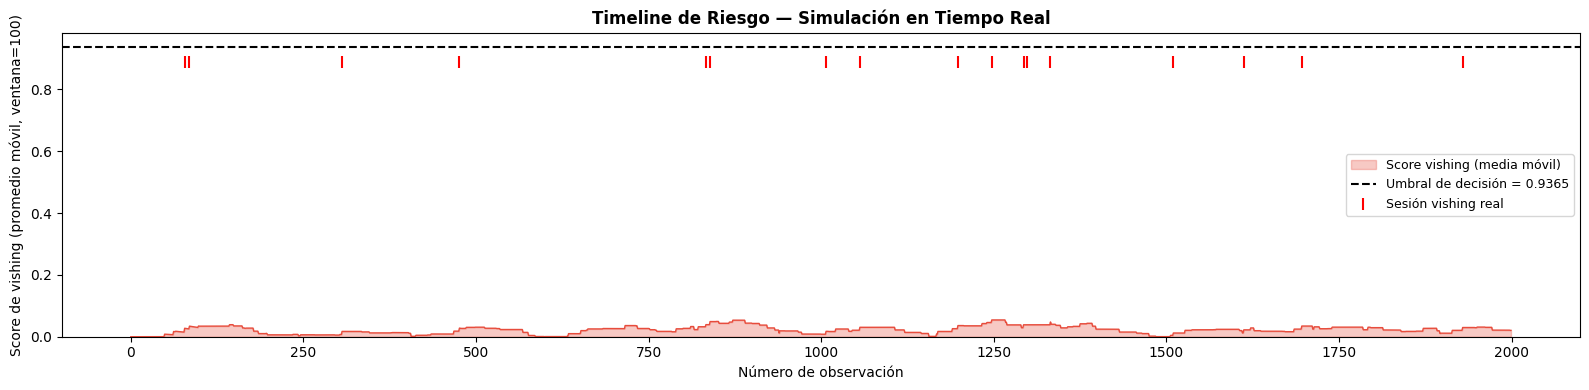

In [36]:
sample_tl = df_results.head(2_000).copy()
sample_tl['rolling_score'] = sample_tl['score_vishing'].rolling(100, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(16, 4))

ax.fill_between(sample_tl.index, sample_tl['rolling_score'],
                alpha=0.3, color='#e74c3c', label='Score vishing (media móvil)')
ax.plot(sample_tl.index, sample_tl['rolling_score'], color='#e74c3c', linewidth=1)
ax.axhline(thr, color='black', linestyle='--', linewidth=1.5,
           label=f'Umbral de decisión = {thr:.4f}')

if has_gt:
    vishing_idx = sample_tl[sample_tl['is_vishing_real'] == 1].index
    ax.scatter(vishing_idx, [thr * 0.95] * len(vishing_idx),
               marker='|', color='red', s=80, linewidths=1.5, label='Sesión vishing real')

ax.set_xlabel('Número de observación')
ax.set_ylabel('Score de vishing (promedio móvil, ventana=100)')
ax.set_title('Timeline de Riesgo — Simulación en Tiempo Real', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, None)

plt.tight_layout()
plt.show()

## 5. Vista de muestra de resultados

In [37]:
display_cols = ['obs_index', 'score_vishing', 'score_legitimate',
                'label_pred', 'threshold_used', 'latency_ms']
if has_gt:
    display_cols.insert(2, 'is_vishing_real')

# Muestra: 5 alertas + 5 legítimas
alerts   = df_results[df_results['prediction'] == 1].head(5)
legit    = df_results[df_results['prediction'] == 0].head(5)
sample_display = pd.concat([alerts, legit])

print('Muestra de resultados (5 alertas + 5 legítimas):')
display(
    sample_display[display_cols]
    .style
    .background_gradient(cmap='RdYlGn_r', subset=['score_vishing'])
    .background_gradient(cmap='Blues', subset=['latency_ms'])
    .format({'score_vishing': '{:.6f}', 'score_legitimate': '{:.6f}',
             'latency_ms': '{:.4f} ms', 'threshold_used': '{:.6f}'})
)

print(f'\nResultados completos disponibles en: {results_path}')

Muestra de resultados (5 alertas + 5 legítimas):


,obs_index,score_vishing,is_vishing_real,score_legitimate,label_pred,threshold_used,latency_ms
78,78,0.992214,1,0.007786,vishing,0.936487,1.9326 ms
306,306,0.986664,1,0.013336,vishing,0.936487,1.7697 ms
476,476,0.990880,1,0.009120,vishing,0.936487,1.7337 ms
716,716,0.986327,0,0.013673,vishing,0.936487,1.6996 ms
790,790,0.956412,0,0.043588,vishing,0.936487,1.7057 ms
0,0,0.000036,0,0.999964,legitimate,0.936487,10.1423 ms
1,1,0.000048,0,0.999952,legitimate,0.936487,1.8510 ms
2,2,0.000025,0,0.999975,legitimate,0.936487,1.4914 ms
3,3,0.000013,0,0.999987,legitimate,0.936487,1.4570 ms
4,4,0.000039,0,0.999961,legitimate,0.936487,1.4712 ms



Resultados completos disponibles en: s3://poc-fraude-vishing/proyecto/data/inference_simulation/results/simulation_results.csv
